In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  ,
    prediction_mode='classification'
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )



/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23281373/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [2]:
data_orchestrator.data_final.data.target_lead1.nunique()

2

# Shallowdataloader

In [3]:
import pandas as pd
import pandas as pd
from typing import Literal, Union, List, Dict
from dataclasses import dataclass

from src.utils.textformatting import warning_emoji, checkmark

@dataclass
class ShallowDataLoader:
    """ 
    Stores a single dataloader for shallow models
    """    
    X: pd.DataFrame
    y: pd.DataFrame

    def __post_init__(self):
            # Validate that X and y have the same number of rows
            if len(self.X) != len(self.y):
                raise ValueError(f"X and y have mismatched lengths: X has {len(self.X)} rows, but y has {len(self.y)} rows.")
            
            if len(self.X) == 0:
                raise ValueError(f"No data found. Please check the timestamps used.")

    def __repr__(self):
        return (f"<ShallowDataLoader(X: {len(self.X)} rows, {len(self.X.columns)} cols, " 
                f"y: {len(self.y)} rows)>")     

@dataclass
class ShallowDataLoaderCollection:
    """ 
    Stores all DataLoaders for shallow models

    See Also
    --------
    ShallowDataLoader
    """
    train:              'ShallowDataLoader'
    val:                'ShallowDataLoader'   
    test:               'ShallowDataLoader'
    main:               pd.DataFrame

    def __repr__(self):
        return (f"<ShallowDataLoaderCollection(train, val, test, main)>") 

class ShallowDataLoaderManagerClasses:
    """
    """
    def __init__(self, 
                 dataorchestrator: DataOrchestrator):
        
        self.dataorchestrator     = dataorchestrator
        self.column_registration  = dataorchestrator.column_registration

    def construct_dataloaders(self):
        """
        create dataloader collection classes and store it in `self.dataloader_collections`.
        """
        main_data           = self.dataorchestrator.data_final.data.copy()
        X_col_selection     = [self.dataorchestrator.config.id_column]+self.column_registration.get_by_type('feature')
        self.dataloader_collections: Dict[str, ShallowDataLoaderCollection]    = {}

        for hh in range(self.dataorchestrator.config.horizon_size):
            horizon_name    = f'horizon_{hh}'
            steps_ahead     = int(hh+self.dataorchestrator.config.horizon_leadtime)
            y_col_selection = f'target_lead{steps_ahead}'
            
            main            = main_data[[self.dataorchestrator.config.temporal_column] + X_col_selection + [y_col_selection] + self.column_registration.get_by_type("split")]
            main            = main.rename(columns = {y_col_selection:'target'}).dropna()

            X_train, y_train= main[main['train']][X_col_selection].reset_index(drop = True),  main[main['train']][['target']]
            X_val, y_val    = main[main['val']][X_col_selection].reset_index(drop = True),    main[main['val']][['target']]
            X_test, y_test  = main[main['test']][X_col_selection].reset_index(drop = True),   main[main['test']][['target']]

            dataloader  = ShallowDataLoaderCollection(
                train = ShallowDataLoader(X_train, y_train),
                val   = ShallowDataLoader(X_val, y_val),
                test  = ShallowDataLoader(X_test, y_test),
                main  = main)

            self.dataloader_collections[horizon_name] = dataloader

            if self.dataorchestrator.config.verbose:
                print(f'{checkmark} Dataloader object created for {horizon_name}')

        return self
    
    def __repr__(self):
        return (f"<ShallowDataLoaderManager(dataloaders for {self.dataorchestrator.config.horizon_size} horizons in self.dataloader_collections)>")            

In [4]:
classified_shallowloader = ShallowDataLoaderManagerClasses(data_orchestrator).construct_dataloaders()

## Persistence

In [ ]:
from src.models import PersistenceModel, ClimateologyModel

ps = PersistenceModel(classified_shallowloader, 'persistence - binary')

ps.forecast()
ps.show_forecasts(26).show()

## Evaluation - persistence

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# classification - metrics
# 0 => no cases
# 1 => cases

preds_df = ps.predictions.test.get_original(0)[['target','pred']]

cm = confusion_matrix(preds_df['target'], preds_df['pred'])
# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No outbreak', 'Outbreak'],
            yticklabels=['No outbreak', 'Outbreak'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


In [27]:
print(ps.predictions.test.get_original(0))

       timestamp  node  target  pred
0     2018-06-11     0     0.0   0.0
1     2018-06-11     1     0.0   0.0
2     2018-06-11     2     0.0   0.0
3     2018-06-11     3     0.0   0.0
4     2018-06-11     4     0.0   0.0
...          ...   ...     ...   ...
41195 2020-05-25   395     0.0   0.0
41196 2020-05-25   396     0.0   0.0
41197 2020-05-25   397     0.0   0.0
41198 2020-05-25   398     0.0   0.0
41199 2020-05-25   399     0.0   0.0

[41200 rows x 4 columns]


In [42]:

from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score

# Group by timestamp and calculate metrics
metrics_per_timestamp = ps.predictions.test.get_original(0).groupby('timestamp').apply(
    lambda x: pd.Series({
        'recall': recall_score(x['target'], x['pred'], zero_division=0),
        'precision': precision_score(x['target'], x['pred'], zero_division=0),
        'accuracy': accuracy_score(x['target'], x['pred']),
        'f1': f1_score(x['target'], x['pred'], zero_division=0),
        'FP_count': ((x['pred'] == 1) & (x['target'] == 0)).sum(),
        'FN_count': ((x['pred'] == 0) & (x['target'] == 1)).sum(),
        'TP_count': ((x['pred'] == 1) & (x['target'] == 1)).sum(),
        'TN_count': ((x['pred'] == 0) & (x['target'] == 0)).sum(),
        'total_actual_positives': (x['target'] == 1).sum(),
        'total_actual_negatives': (x['target'] == 0).sum()
    })
).reset_index()

# Calculate rates
metrics_per_timestamp['FPR'] = metrics_per_timestamp['FP_count'] / metrics_per_timestamp['total_actual_negatives']
metrics_per_timestamp['FNR'] = metrics_per_timestamp['FN_count'] / metrics_per_timestamp['total_actual_positives']

# Handle division by zero (when no positives or negatives exist)
metrics_per_timestamp['FPR'] = metrics_per_timestamp['FPR'].fillna(0)
metrics_per_timestamp['FNR'] = metrics_per_timestamp['FNR'].fillna(0)

print(metrics_per_timestamp)

     timestamp    recall  precision  accuracy        f1  FP_count  FN_count  \
0   2018-06-11  0.700000   0.538462    0.9775  0.608696       6.0       3.0   
1   2018-06-18  0.363636   0.400000    0.9675  0.380952       6.0       7.0   
2   2018-06-25  0.285714   0.181818    0.9650  0.222222       9.0       5.0   
3   2018-07-02  0.153846   0.285714    0.9600  0.200000       5.0      11.0   
4   2018-07-09  0.666667   0.461538    0.9750  0.545455       7.0       3.0   
..         ...       ...        ...       ...       ...       ...       ...   
98  2020-04-27  0.000000   0.000000    1.0000  0.000000       0.0       0.0   
99  2020-05-04  0.000000   0.000000    1.0000  0.000000       0.0       0.0   
100 2020-05-11  0.000000   0.000000    1.0000  0.000000       0.0       0.0   
101 2020-05-18  0.000000   0.000000    1.0000  0.000000       0.0       0.0   
102 2020-05-25  0.000000   0.000000    1.0000  0.000000       0.0       0.0   

     TP_count  TN_count  total_actual_positives  to

/local/job_23281373/ipykernel_156479/2704184169.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_per_timestamp = ps.predictions.test.get_original(0).groupby('timestamp').apply(


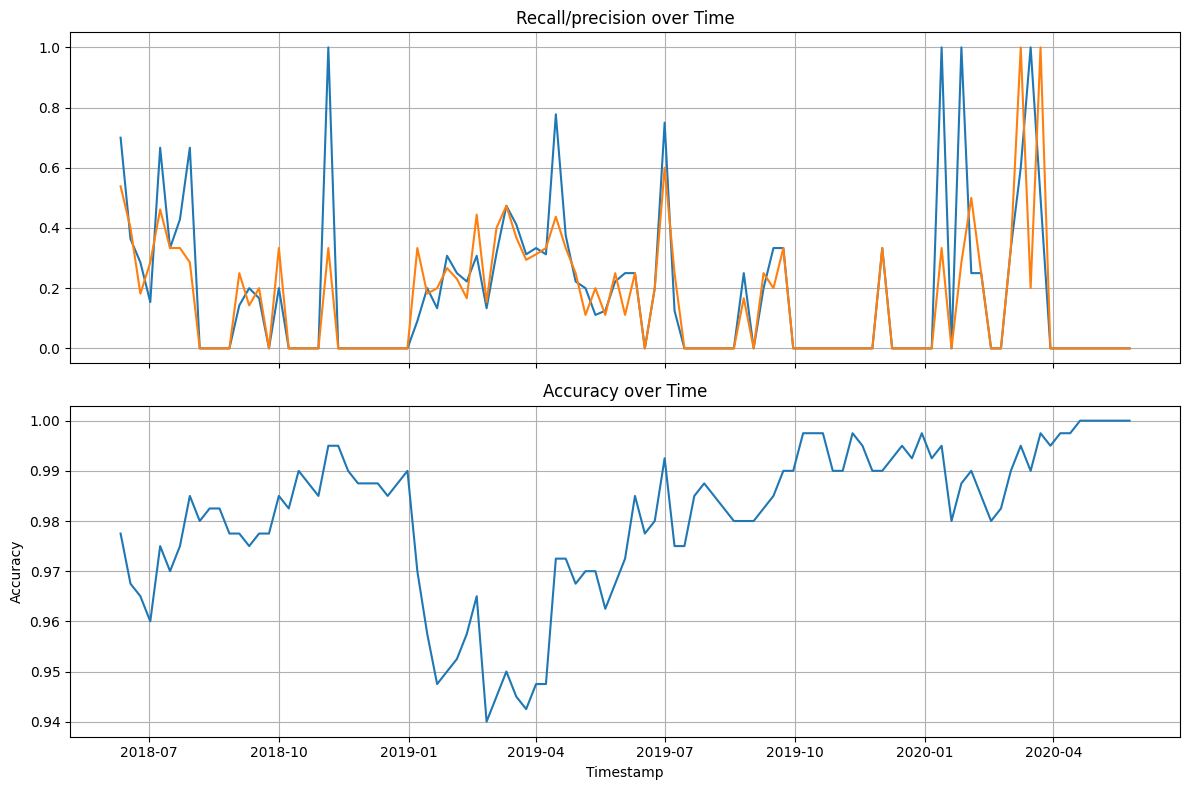

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['recall'])
axes[0].set_title('Recall/precision over Time')
axes[0].grid(True)
axes[0].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['precision'])


axes[1].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['accuracy'])
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Timestamp')
axes[1].set_title('Accuracy over Time')
axes[1].grid(True)


plt.tight_layout()
plt.show()

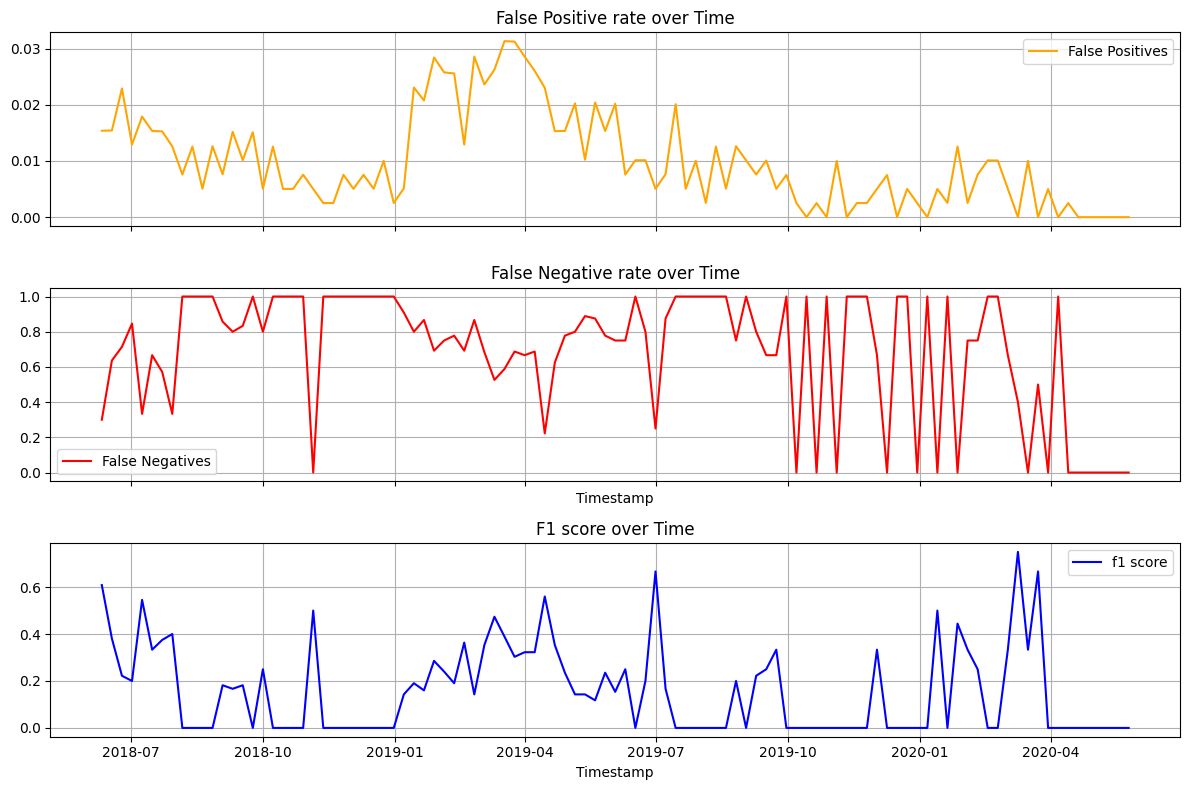

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['FPR'], label='False Positives', color='orange')
# axes[0].set_ylabel('Count')
axes[0].set_title('False Positive rate over Time')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['FNR'], label='False Negatives', color='red')
# axes[1].set_ylabel('Count')
axes[1].set_xlabel('Timestamp')
axes[1].set_title('False Negative rate over Time')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(metrics_per_timestamp['timestamp'], metrics_per_timestamp['f1'], label='f1 score', color='blue')
# axes[2].set_ylabel('Count')
axes[2].set_xlabel('Timestamp')
axes[2].set_title('F1 score over Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [45]:
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

df = ps.predictions.test.get_original(0)

metrics_per_node = df.groupby('node').apply(
    lambda x: pd.Series({
        'f1': f1_score(x['target'], x['pred'], zero_division=0),
        'recall': recall_score(x['target'], x['pred'], zero_division=0),
        'precision': precision_score(x['target'], x['pred'], zero_division=0),
        'accuracy': accuracy_score(x['target'], x['pred']),
        'FP_count': ((x['pred'] == 1) & (x['target'] == 0)).sum(),
        'FN_count': ((x['pred'] == 0) & (x['target'] == 1)).sum(),
        'TP_count': ((x['pred'] == 1) & (x['target'] == 1)).sum(),
        'TN_count': ((x['pred'] == 0) & (x['target'] == 0)).sum(),
        'total_actual_positives': (x['target'] == 1).sum(),
        'total_actual_negatives': (x['target'] == 0).sum()
    })
).reset_index()

# Calculate rates
metrics_per_node['FPR'] = metrics_per_node['FP_count'] / metrics_per_node['total_actual_negatives']
metrics_per_node['FNR'] = metrics_per_node['FN_count'] / metrics_per_node['total_actual_positives']

metrics_per_node['FPR'] = metrics_per_node['FPR'].fillna(0)
metrics_per_node['FNR'] = metrics_per_node['FNR'].fillna(0)

print(metrics_per_node[['node', 'f1', 'recall', 'precision', 'total_actual_positives']])

     node   f1  recall  precision  total_actual_positives
0       0  0.0     0.0        0.0                     1.0
1       1  0.0     0.0        0.0                     0.0
2       2  0.0     0.0        0.0                     1.0
3       3  0.0     0.0        0.0                     0.0
4       4  0.0     0.0        0.0                     1.0
..    ...  ...     ...        ...                     ...
395   395  0.0     0.0        0.0                     0.0
396   396  0.0     0.0        0.0                     0.0
397   397  0.0     0.0        0.0                     0.0
398   398  0.0     0.0        0.0                     0.0
399   399  0.0     0.0        0.0                     0.0

[400 rows x 5 columns]


/local/job_23281373/ipykernel_156479/2374985611.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_per_node = df.groupby('node').apply(


/local/job_23281373/ipykernel_156479/3595955111.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


[Text(0, 0, '')]

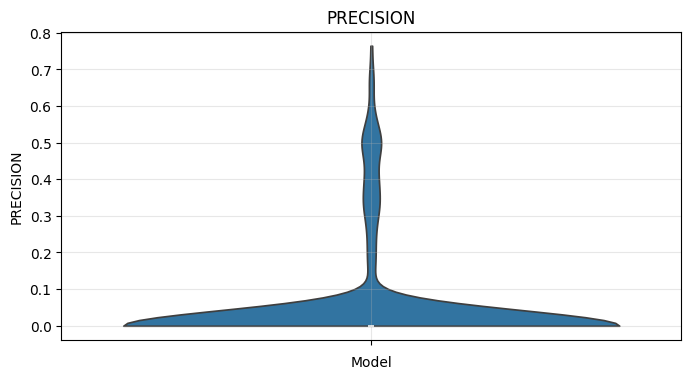

In [53]:
plot_type = 'violin'
fig, ax = plt.subplots(1,1,figsize= (8,4))
metric = 'precision'

plot_func = sns.violinplot if plot_type == 'violin' else sns.boxplot
plot_func(
    data=metrics_per_node, y=metric,
    ax=ax,
    **(dict(cut=0) if plot_type == 'violin' else {}),
    legend=False
)

ax.set_title(f'{metric.upper()}')
ax.set_ylabel(metric.upper())
ax.set_xlabel('Model')
ax.grid(alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


## DeepLoader

In [59]:
deepdata = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()